<a href="https://colab.research.google.com/github/Jawntae/neetcode-submissions/blob/main/23-multiclass_classification_worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worksheet: Multi-Class Classification

In this worksheet you will build and evaluate a multi-class classifier, then reflect on how dataset size, number of classes, and class imbalance affect classification and performance evaluation.

**Instructions:** Read each section and write your code in the empty code cells below it. Write your written answers in the marked markdown cells.

## Part 1: Handwritten Digits Dataset

In this part, you will use the **Digits** dataset from scikit-learn. Each observation is an image of a handwritten digit from 0 to 9. You will use the pixel values as features and logistic regression to predict the digit.

Start by importing the libraries you will need.

In [35]:
# Import the libraries you will need (e.g. numpy, pandas, matplotlib, scikit-learn)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #added

from sklearn.datasets import fetch_20newsgroups
from sklearn.datasets import load_digits  #added
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
)

### 1. Introduce the dataset

Load the Digits dataset and examine:

* Number of images
* Image dimensions
* Number of features
* Number of classes

In [29]:
# Load the Digits dataset
digits = load_digits()


In [30]:
# Print the number of images, image dimensions, number of features, and number of classes
# Assumes 'digits' is correctly loaded as sklearn.datasets.load_digits() from the previous cell.

# Number of images
print(f"Number of images: {digits.images.shape[0]}")

# Image dimensions (e.g., for an 8x8 image, this would be (8, 8))
print(f"Image dimensions: {digits.images.shape[1:]}")

# Number of features (total pixels per image)
print(f"Number of features: {digits.data.shape[1]}")

# Number of classes (digits 0-9)
print(f"Number of classes: {len(digits.target_names)}")

Number of images: 1797
Image dimensions: (8, 8)
Number of features: 64
Number of classes: 10


Display a few sample images and their corresponding labels.

In [34]:
# Display a few sample images with their labels
df = pd.DataFrame(digits.data)
df['target'] = digits.target
df.sample(10)

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
1303,0.0,0.0,0.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,1.0,11.0,16.0,16.0,12.0,0.0,6
167,0.0,0.0,2.0,13.0,8.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,12.0,16.0,16.0,1.0,0.0,9
265,0.0,0.0,6.0,12.0,13.0,5.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,3.0,16.0,14.0,0.0,0.0,0.0,9
136,0.0,0.0,2.0,15.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,13.0,16.0,16.0,8.0,0.0,6
674,0.0,0.0,3.0,13.0,14.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4.0,14.0,15.0,12.0,4.0,0.0,8
520,0.0,0.0,1.0,14.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,5.0,0.0,0.0,0.0,4
303,0.0,0.0,0.0,10.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,5.0,7.0,15.0,8.0,0.0,1
766,0.0,3.0,10.0,16.0,16.0,16.0,2.0,0.0,0.0,14.0,...,0.0,0.0,2.0,15.0,16.0,8.0,0.0,0.0,0.0,5
1569,0.0,0.0,0.0,1.0,13.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,11.0,11.0,1.0,0.0,6
266,0.0,0.0,4.0,13.0,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,7.0,15.0,11.0,2.0,0.0,0.0,0


### 2. Explore the data

Explore the pixel values and briefly describe what each feature represents.

Min pixel value: 0.0
Max pixel value: 16.0
Mean pixel value: 4.884164579855314
Standard deviation of pixel values: 6.016787548672236
Single image's feature vector: [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


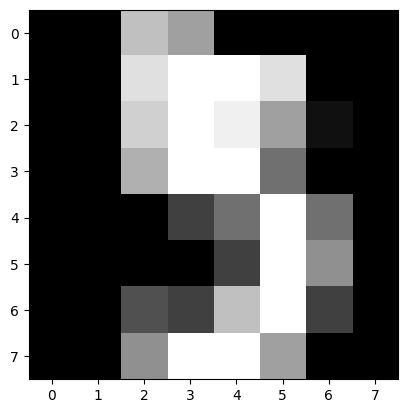

In [44]:
# Explore the pixel values (e.g. range, mean, distribution, a single image's feature vector)
print(f"Min pixel value: {digits.data.min()}")
print(f"Max pixel value: {digits.data.max()}")
print(f"Mean pixel value: {digits.data.mean()}")
print(f"Standard deviation of pixel values: {digits.data.std()}")
print(f"Single image's feature vector: {digits.data[0]}")
plt.imshow(digits.images[5], cmap='gray')
plt.show()


Let's visualize the distribution of all pixel values across the entire dataset to get a better sense of their range and frequency.

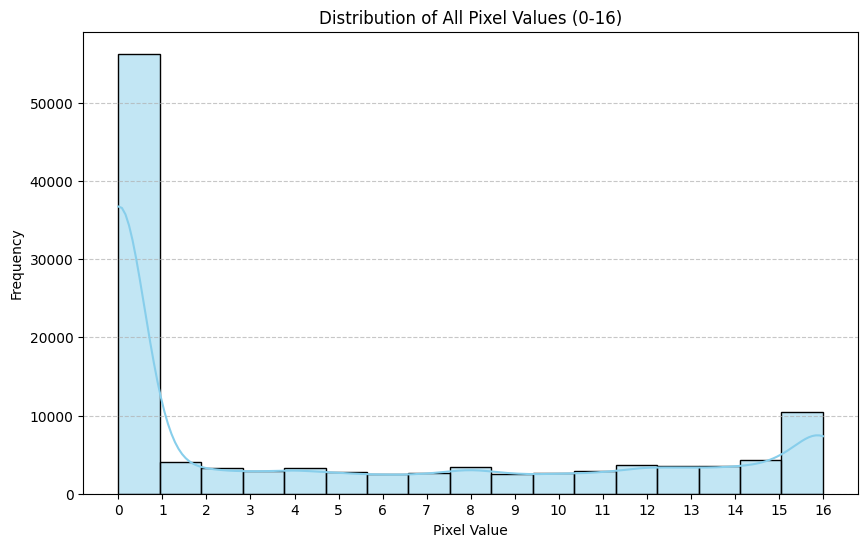

In [41]:
# Flatten the data to get all pixel values into a single array
all_pixel_values = digits.data.flatten()

# Create a histogram of the pixel values
fig = plt.figure(figsize=(10, 6))
sns.histplot(all_pixel_values, bins=17, kde=True, color='skyblue')
plt.title('Distribution of All Pixel Values (0-16)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(0, 17)) # Ensure all integer pixel values are shown on x-axis
plt.show()


**Your answer:** What does each feature represent?

*Write your answer here.*

**Each feature represents a value in a vector that is used to draw the digit**

### 3. Check the classes

Count how many images belong to each digit (0–9).

In [45]:
# Count the number of images per class and visualise the class distribution
print(df['target'].value_counts())

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64


**Your answer:** Are the classes approximately balanced?

*Write your answer here.*

**yes, They seemed to balanced**

### 4. Classification

Split the data into training and testing sets. Then:

* Fit a multinomial logistic regression model.
* Use the test set to make predictions.
* Report the test accuracy.

In [46]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)

In [47]:
# Fit a multinomial logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial')
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial')

In [48]:
# Make predictions on the test set and report the test accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")


Test Accuracy: 0.9694444444444444


### 5. Performance metrics

Evaluate the model using:

* Confusion matrix
* Precision
* Recall
* F1-score
* Accuracy

In [49]:
# Compute and display the confusion matrix
confusion = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion)


Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 44  0  1  0  0  0]
 [ 0  0  1  0  0 44  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


In [52]:
# Compute precision, recall, F1-score, and accuracy (per class and overall)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
accuracy = accuracy_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score
}, index=digits.target_names)

print("Per-Class Metrics:")
display(metrics_df)

print(f"\nOverall Accuracy: {accuracy:.4f}")

Per-Class Metrics:


,Precision,Recall,F1-Score
0,1.000000,1.000000,1.000000
1,0.965517,1.000000,0.982456
2,0.970588,1.000000,0.985075
3,0.970588,0.970588,0.970588
4,1.000000,0.956522,0.977778
5,0.916667,0.936170,0.926316
6,0.944444,0.971429,0.957746
7,1.000000,0.970588,0.985075
8,0.966667,0.966667,0.966667
9,0.974359,0.950000,0.962025



Overall Accuracy: 0.9694


**Your answers:**

*   **Which digits are classified most accurately?**

    Based on the F1-Scores, **Digit 0** is classified perfectly (F1-Score: 1.0). **Digits 2 and 7** also perform exceptionally well (F1-Scores: ~0.985).

*   **Which digits are most often confused with other digits?**

    **Digit 5** is the most commonly confused digit, being misclassified as 2, 6, and 9, and also being the target of misclassifications from other digits (e.g., 3, 4, 6, 7, 8). **Digit 9** is also sometimes confused with digits 3 and 8.

*   **Is accuracy alone enough to describe the model's performance?**

    **No, accuracy alone is generally not enough.** While an overall accuracy of 96.94% is very good, it doesn't reveal the specific strengths and weaknesses of the model for individual classes. Precision, recall, and F1-score provide a more detailed per-class breakdown, showing that while most digits are classified very well, some digits (like Digit 5, with a slightly lower F1-Score of 0.926) are marginally more challenging for the model. This detailed insight helps in understanding where the model could be improved, which global accuracy would not convey.